# IMPORT & CONVERT FILE TYPE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df1 = pd.read_csv('CAD_dataset.csv')

# EXPLORATORY DATA ANALYSIS

In [3]:
df1.sample(5)

,Age,Weight,Length,Male,Female,BMI,DM,HTN,Current Smoker,EX-Smoker,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
275,60,65,160,0,1,25.390625,0,1,0,0,...,4.2,138,6300,34,60,196,50,0,1,1
70,52,70,162,0,1,26.672763,1,1,0,0,...,4.4,143,4900,55,32,218,55,0,0,0
217,50,98,175,1,0,32.000000,0,1,0,0,...,3.0,139,9000,27,61,220,50,0,1,0
156,67,67,155,0,1,27.887617,1,1,0,0,...,4.7,136,7200,25,65,177,40,0,1,1
9,60,71,170,1,0,24.567474,1,0,0,0,...,4.6,140,4900,55,42,380,40,2,0,1


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    303 non-null    int64  
 1   Weight                 303 non-null    int64  
 2   Length                 303 non-null    int64  
 3   Male                   303 non-null    int64  
 4   Female                 303 non-null    int64  
 5   BMI                    303 non-null    float64
 6   DM                     303 non-null    int64  
 7   HTN                    303 non-null    int64  
 8   Current Smoker         303 non-null    int64  
 9   EX-Smoker              303 non-null    int64  
 10  FH                     303 non-null    int64  
 11  Obesity                303 non-null    int64  
 12  CRF                    303 non-null    int64  
 13  CVA                    303 non-null    int64  
 14  Airway disease         303 non-null    int64  
 15  Thyroi

In [5]:
df1.isnull().sum()

,0
Age,0
Weight,0
Length,0
Male,0
Female,0
BMI,0
DM,0
HTN,0
Current Smoker,0
EX-Smoker,0


In [6]:
df1.duplicated().sum()

np.int64(0)

In [7]:
df1.describe()

,Age,Weight,Length,Male,Female,BMI,DM,HTN,Current Smoker,EX-Smoker,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,...,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,58.897690,73.831683,164.716172,0.580858,0.419142,27.248339,0.297030,0.590759,0.207921,0.033003,...,4.230693,140.996700,7562.046205,32.399340,60.148515,221.488449,47.231023,0.620462,0.778878,0.712871
std,10.392278,11.987358,9.327661,0.494235,0.494235,4.098865,0.457706,0.492507,0.406491,0.178941,...,0.458202,3.807885,2413.739323,9.972592,10.182493,60.796199,8.927194,1.132531,0.755082,0.453171
min,30.000000,48.000000,140.000000,0.000000,0.000000,18.115413,0.000000,0.000000,0.000000,0.000000,...,3.000000,128.000000,3700.000000,7.000000,32.000000,25.000000,15.000000,0.000000,0.000000,0.000000
25%,51.000000,65.000000,158.000000,0.000000,0.000000,24.514380,0.000000,0.000000,0.000000,0.000000,...,3.900000,139.000000,5800.000000,26.000000,52.500000,183.500000,45.000000,0.000000,0.000000,0.000000
50%,58.000000,74.000000,165.000000,1.000000,0.000000,26.775510,0.000000,1.000000,0.000000,0.000000,...,4.200000,141.000000,7100.000000,32.000000,60.000000,210.000000,50.000000,0.000000,1.000000,1.000000
75%,66.000000,81.000000,171.000000,1.000000,1.000000,29.411765,1.000000,1.000000,0.000000,0.000000,...,4.500000,143.000000,8800.000000,39.000000,67.000000,250.000000,55.000000,1.000000,1.000000,1.000000
max,86.000000,120.000000,188.000000,1.000000,1.000000,40.900658,1.000000,1.000000,1.000000,1.000000,...,6.600000,156.000000,18000.000000,60.000000,89.000000,742.000000,60.000000,4.000000,3.000000,1.000000


## Cek Korelasi

In [8]:
correlation_matrix = df1.corr()


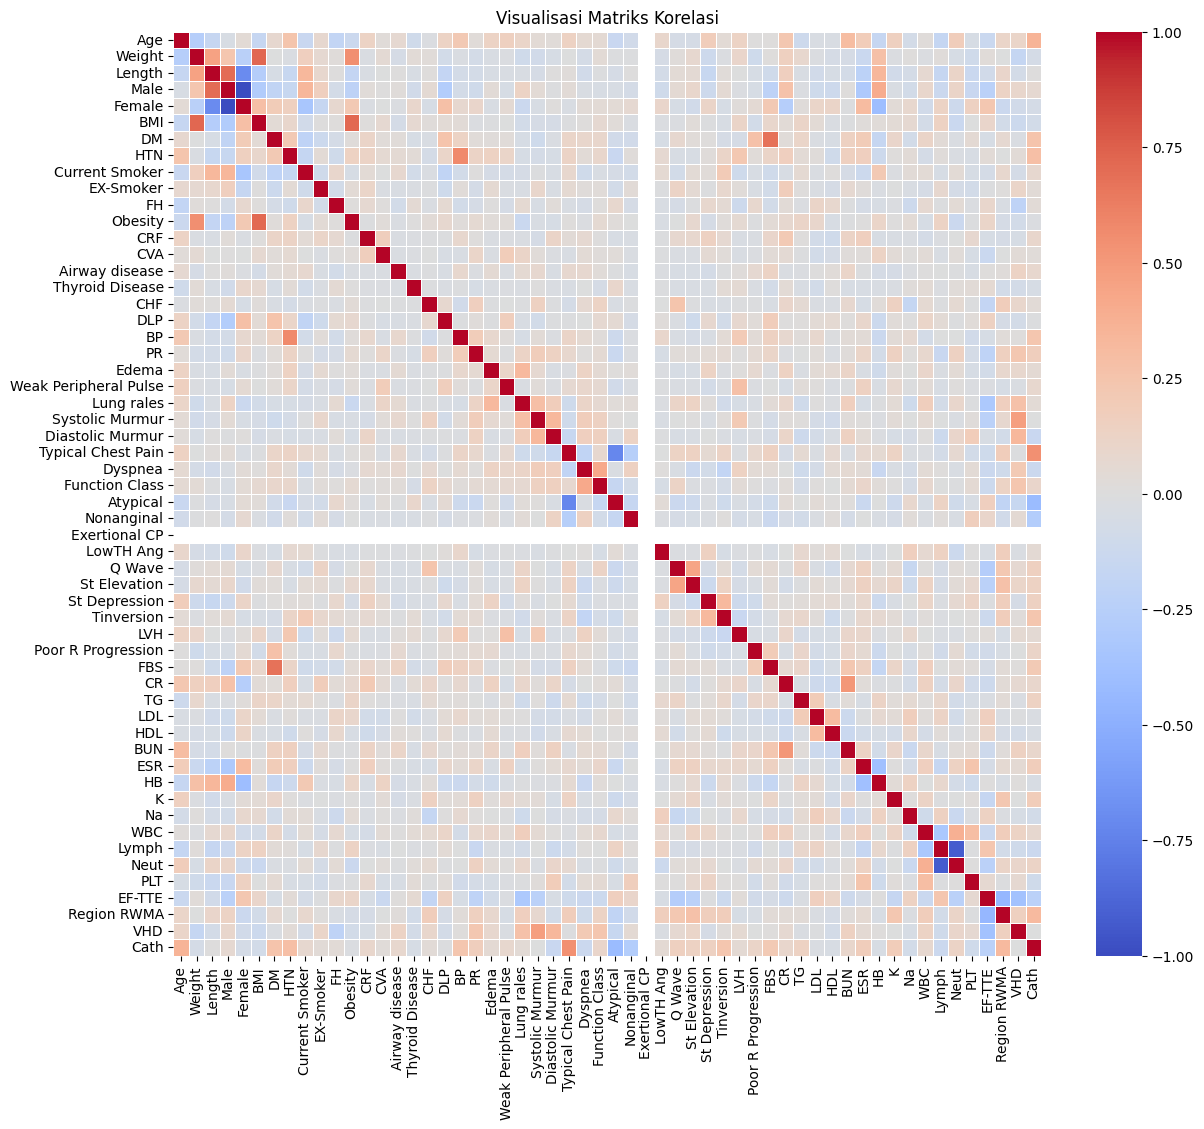

In [9]:
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=.5)
plt.title('Visualisasi Matriks Korelasi')
plt.show()

## Cek Outliers

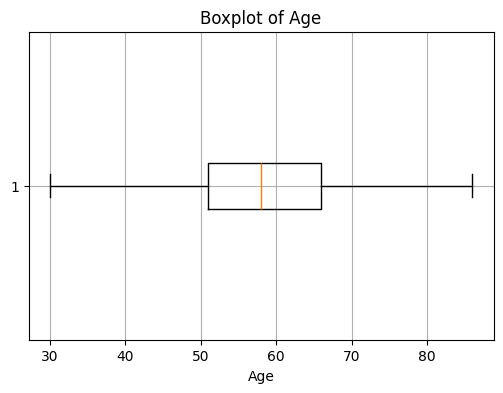

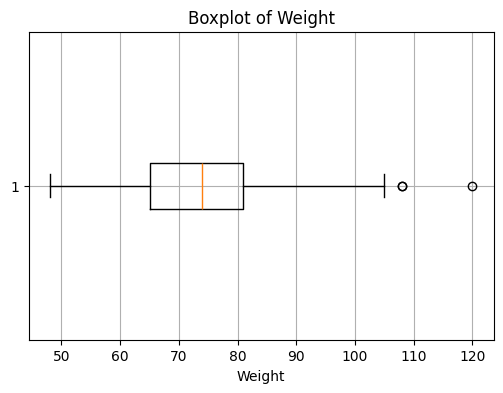

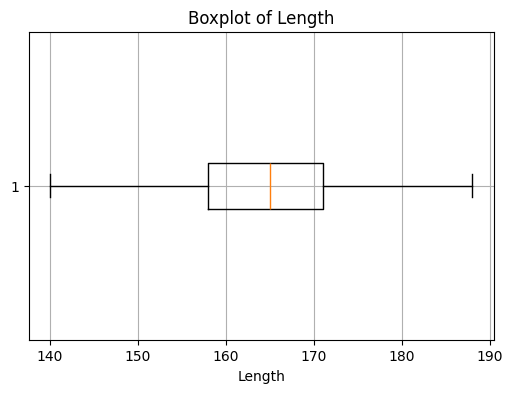

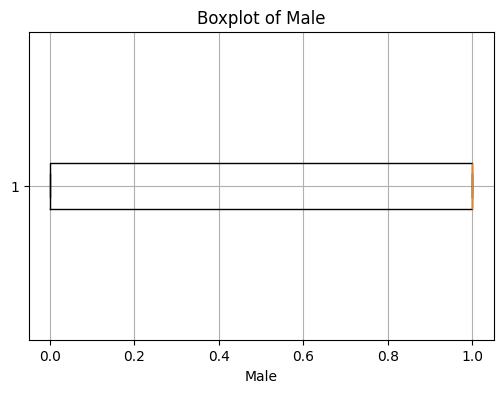

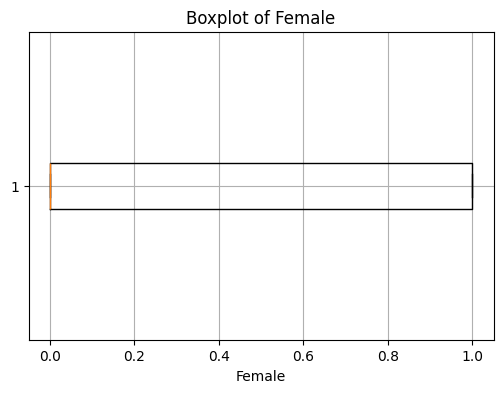

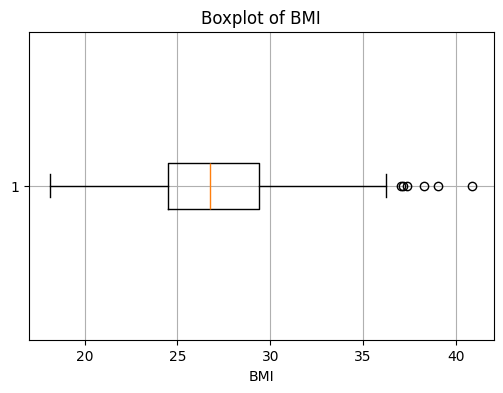

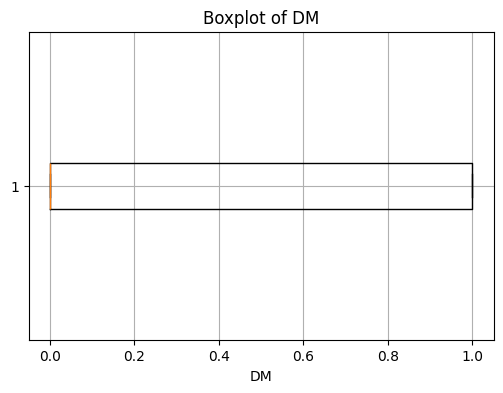

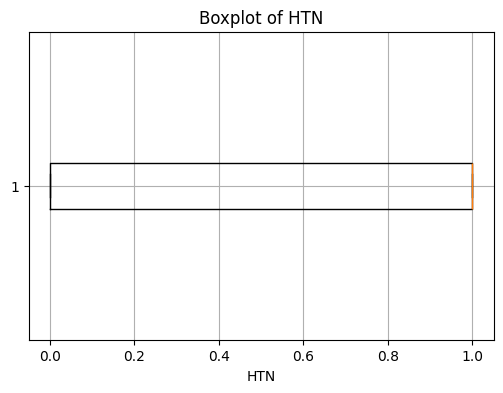

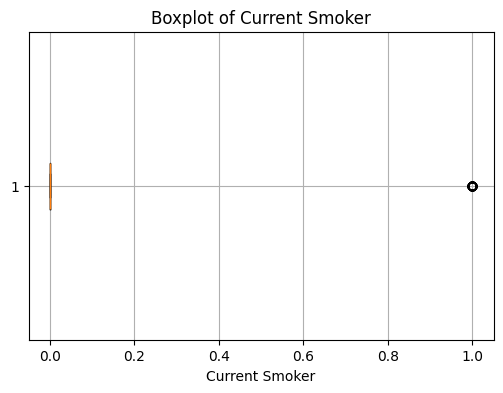

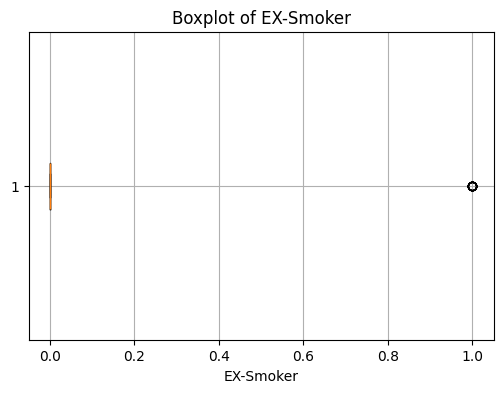

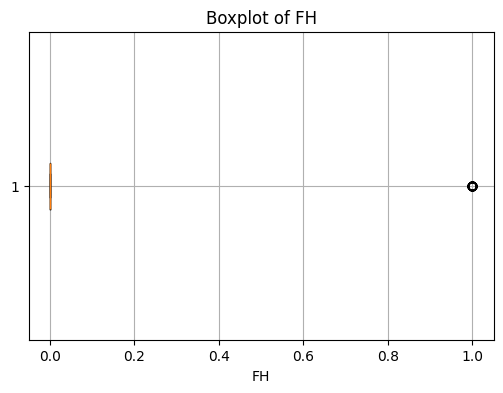

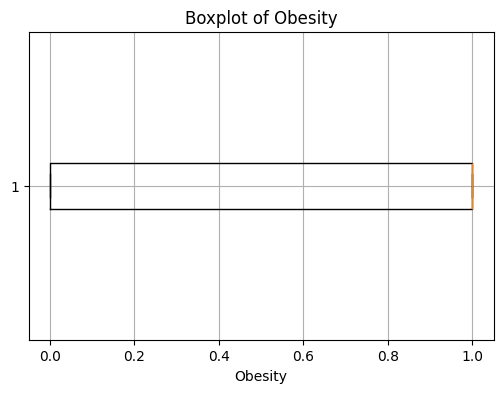

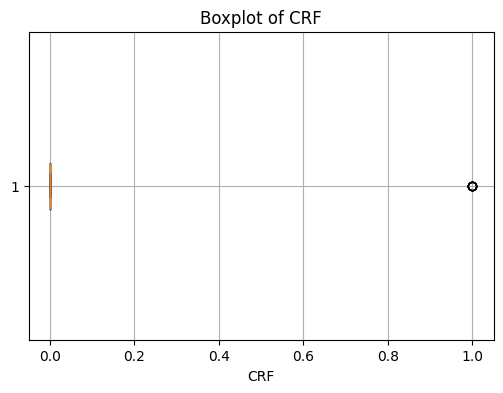

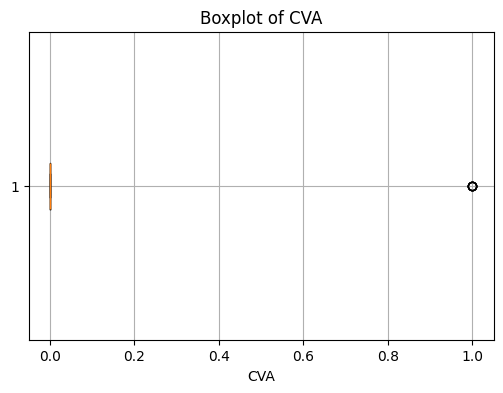

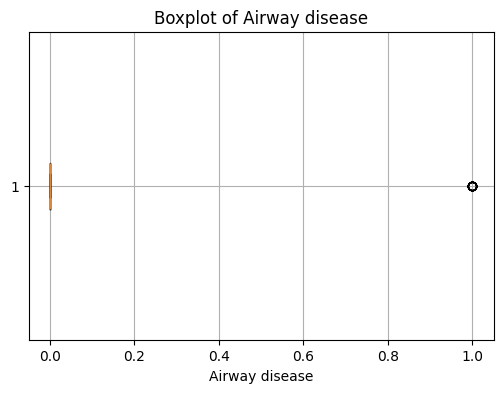

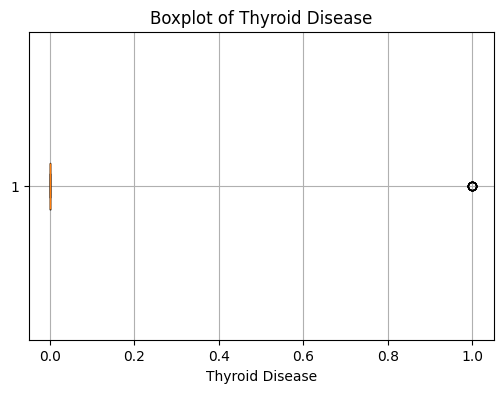

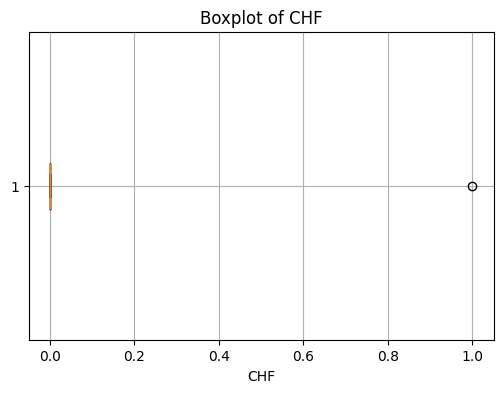

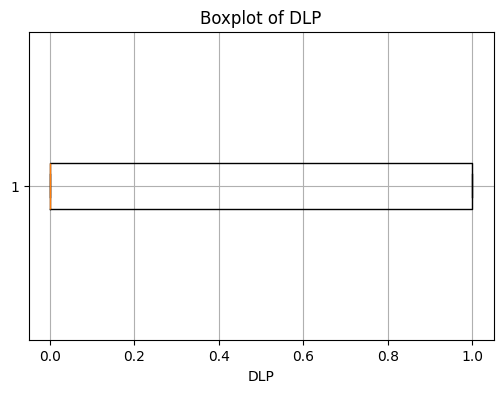

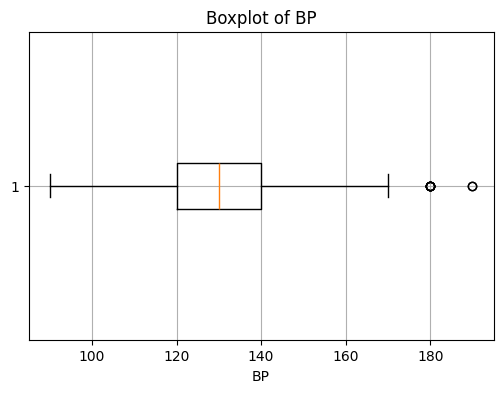

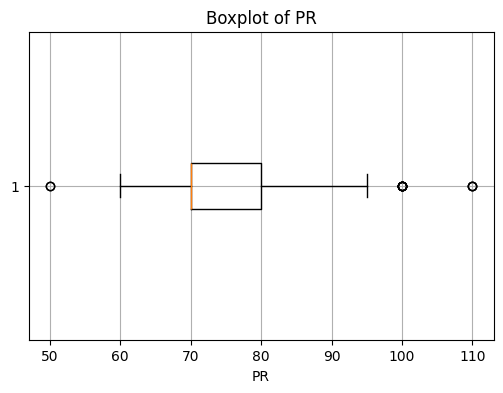

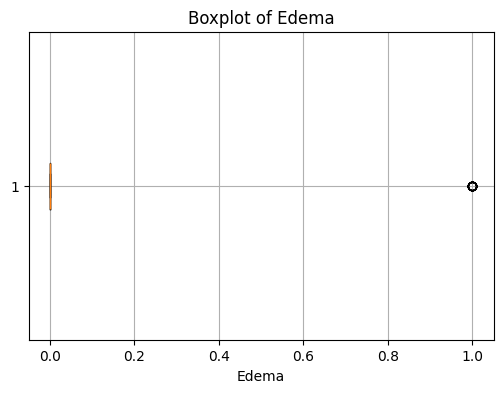

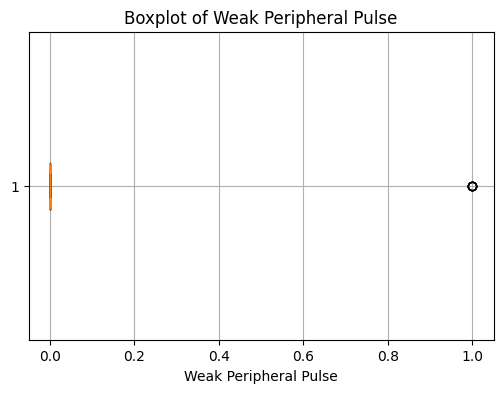

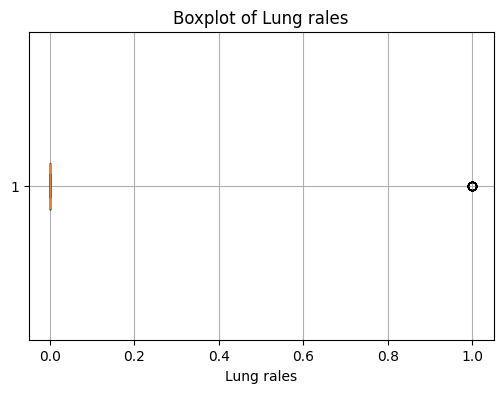

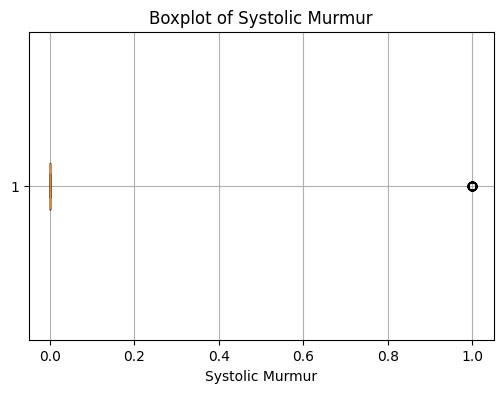

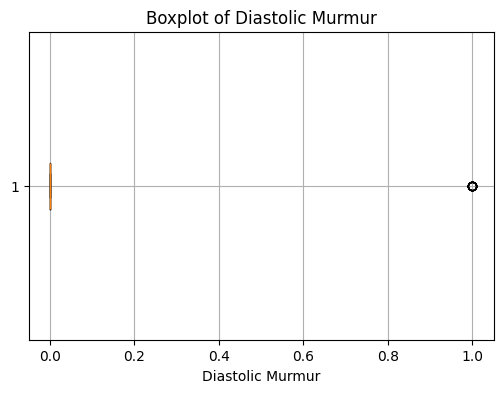

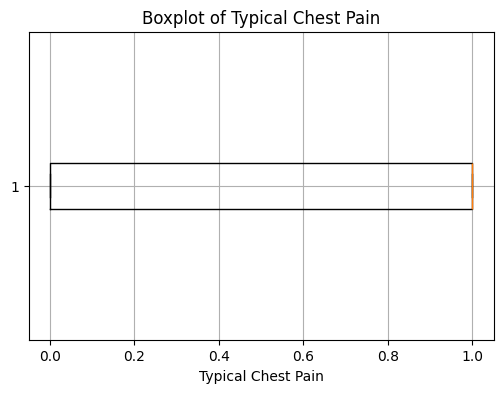

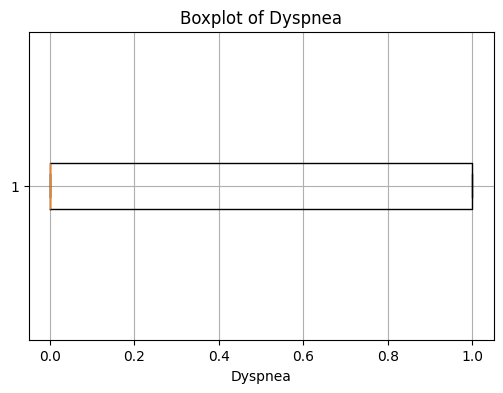

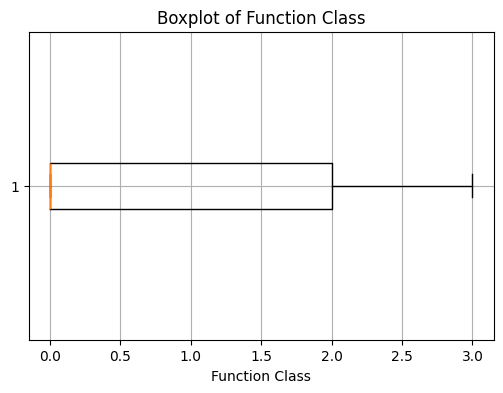

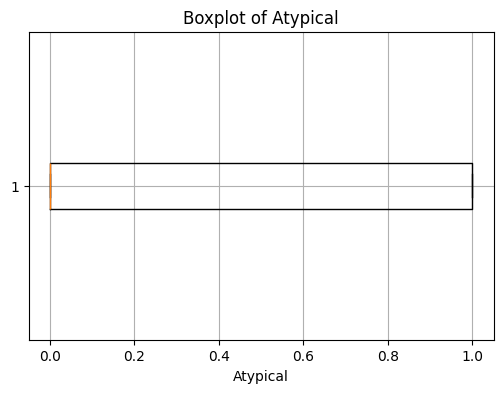

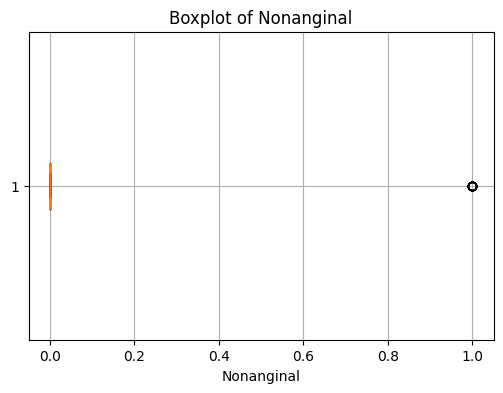

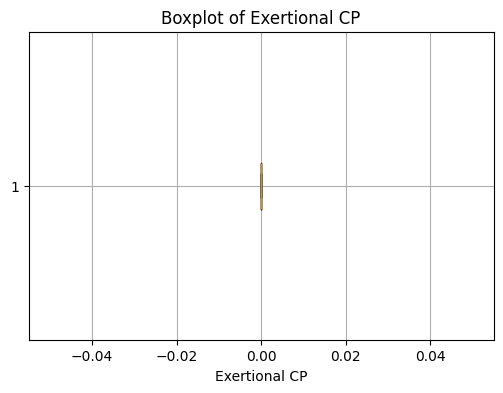

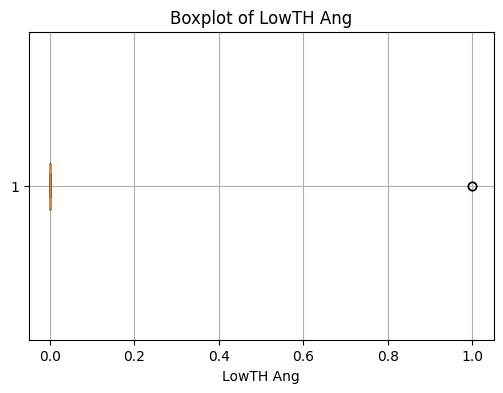

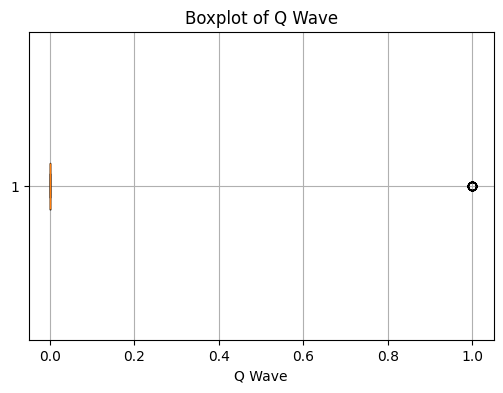

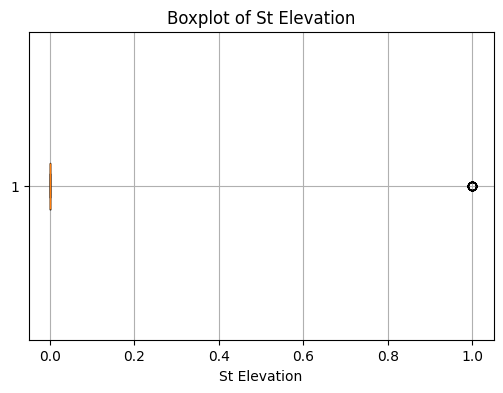

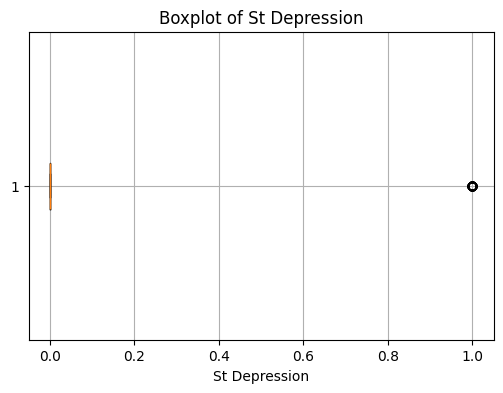

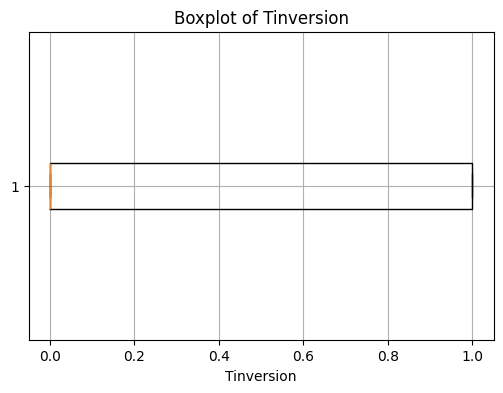

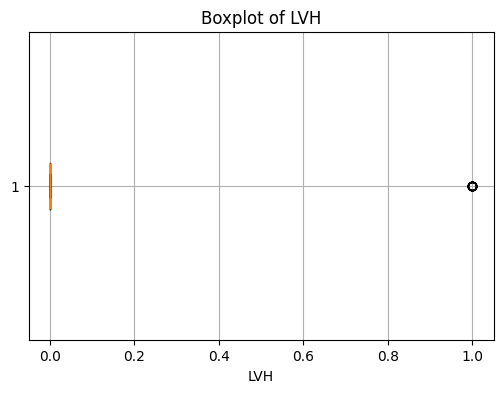

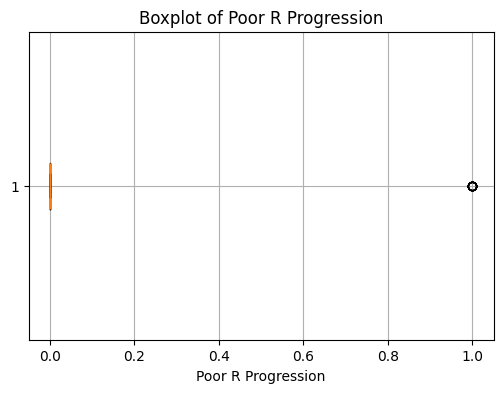

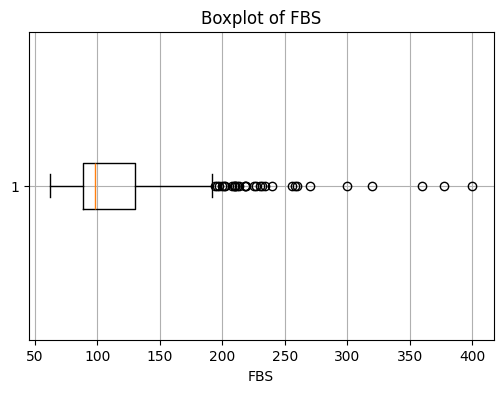

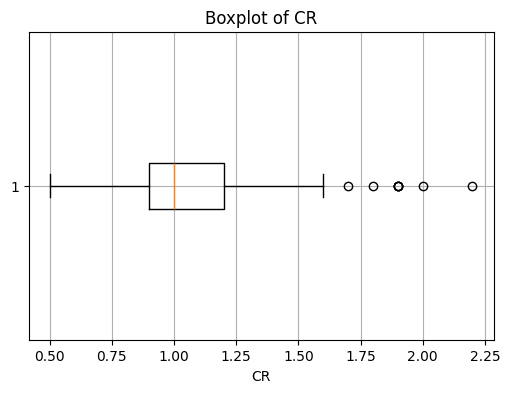

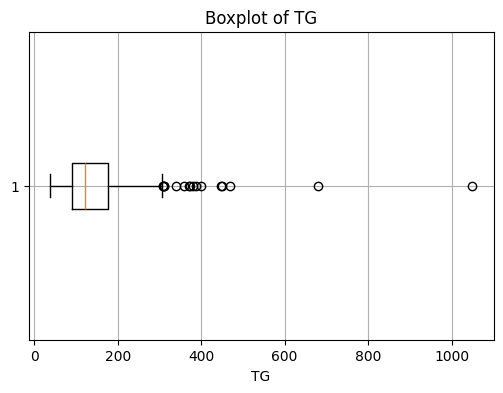

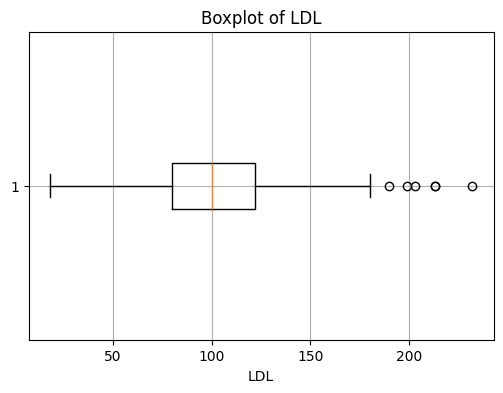

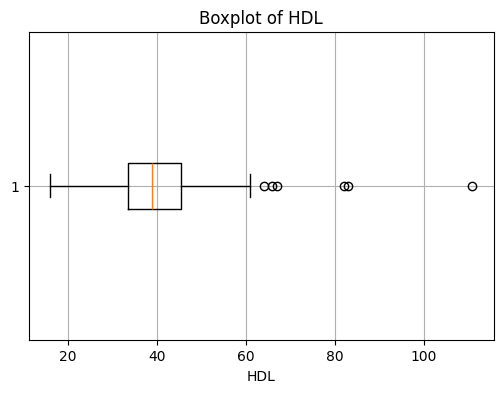

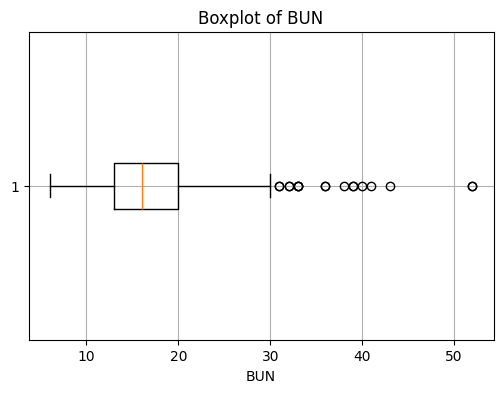

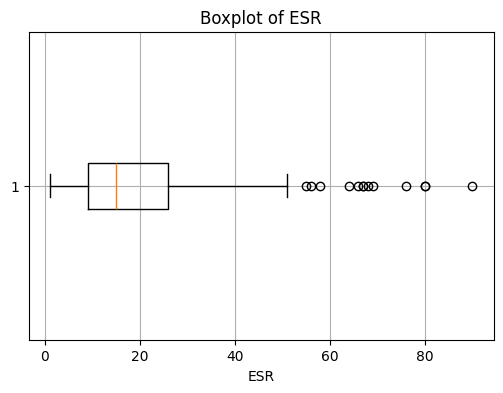

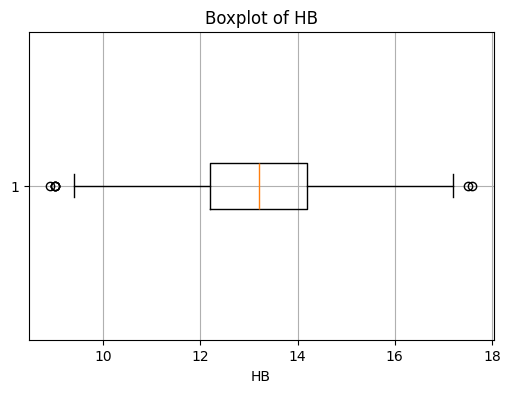

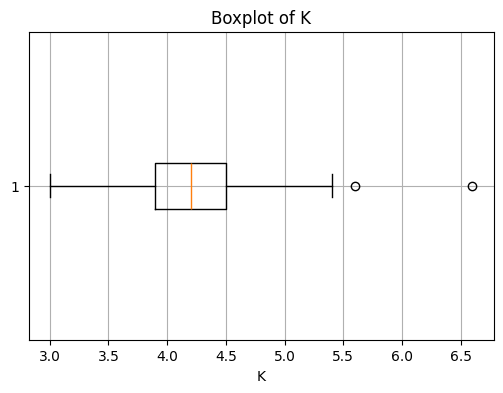

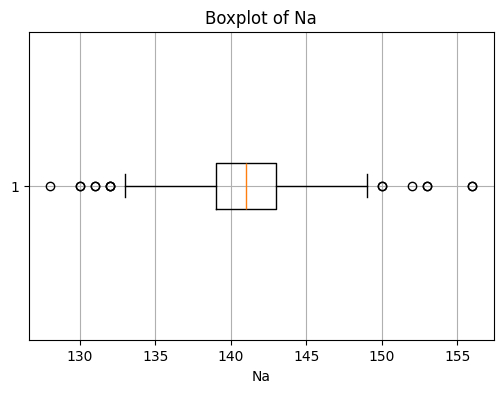

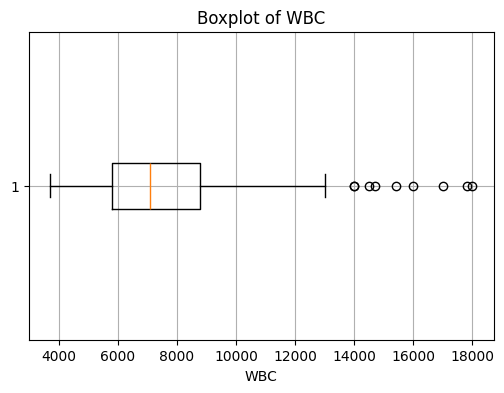

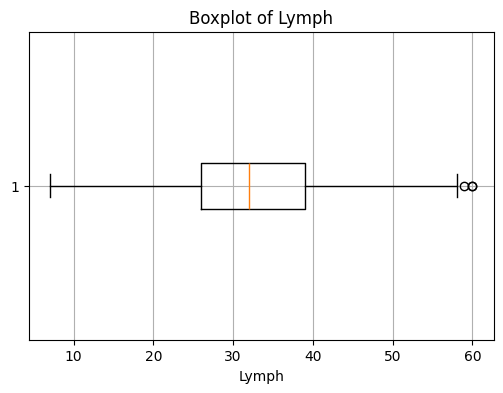

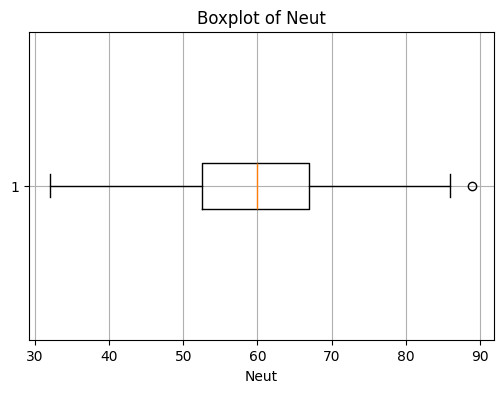

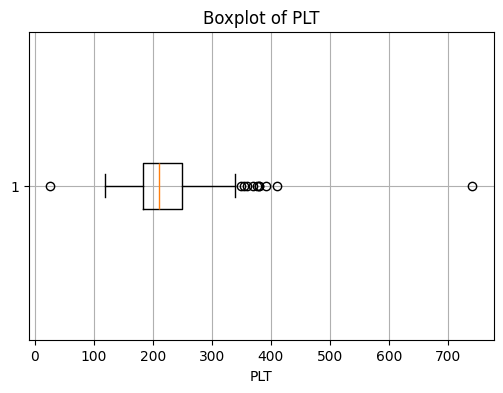

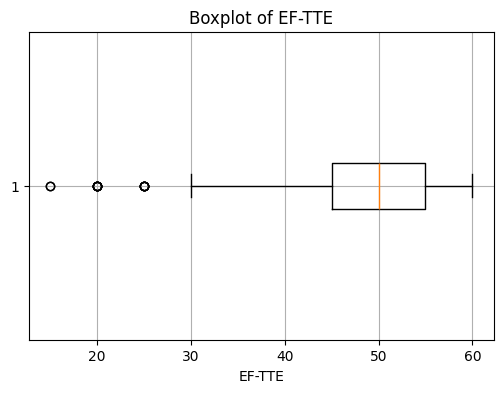

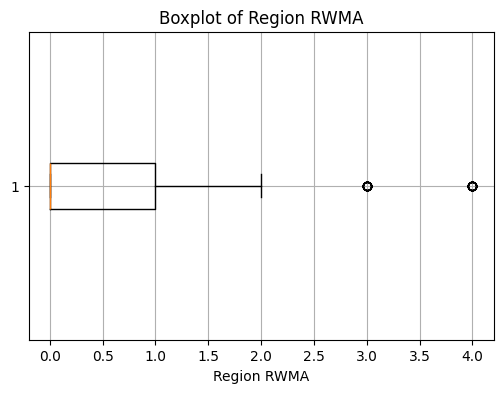

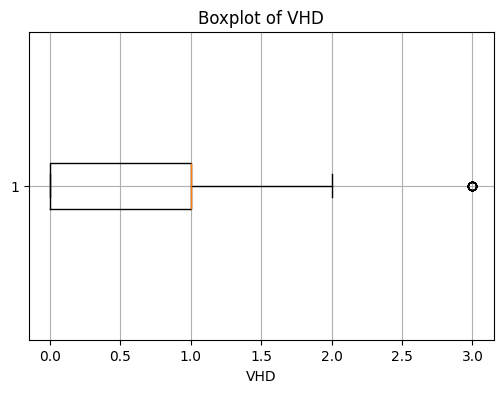

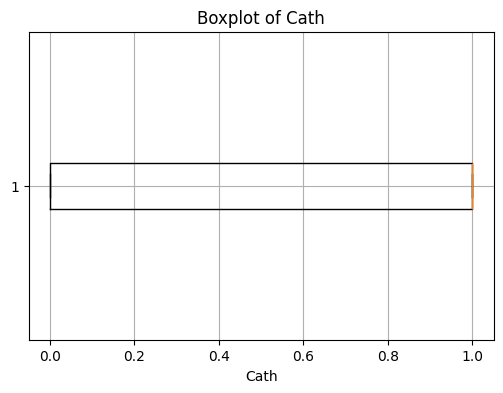

In [10]:
for col in df1.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df1[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.show()

# Supervised

## Normalisasi

In [11]:
X = df1.drop('Cath', axis=1)
y = df1['Cath']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

## Pembangunan dan Perbandingan Model

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost' : XGBClassifier(),
    'LightGBM' : LGBMClassifier(verbose=-1),
    'MLP' : MLPClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("=====================================================")
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.67      0.71        18
           1       0.87      0.91      0.89        43

    accuracy                           0.84        61
   macro avg       0.81      0.79      0.80        61
weighted avg       0.83      0.84      0.83        61


KNN
              precision    recall  f1-score   support

           0       0.73      0.44      0.55        18
           1       0.80      0.93      0.86        43

    accuracy                           0.79        61
   macro avg       0.76      0.69      0.71        61
weighted avg       0.78      0.79      0.77        61


SVM
              precision    recall  f1-score   support

           0       0.83      0.56      0.67        18
           1       0.84      0.95      0.89        43

    accuracy                           0.84        61
   macro avg       0.84      0.75      0.78        61
weighted avg       0.84      0.84      0.83

## Voting Classifier

In [13]:
estimators_scaled = [(name, model) for name, model in models.items()]
voting_clf_scaled = VotingClassifier(estimators=estimators_scaled, voting='soft')

voting_clf_scaled.fit(X_train, y_train)
y_pred_scaled = voting_clf_scaled.predict(X_test)

voting_results_scaled = {
    "classification_report": classification_report(y_test, y_pred_scaled, output_dict=False)
}
print(f"{voting_results_scaled['classification_report']}")

              precision    recall  f1-score   support

           0       0.87      0.72      0.79        18
           1       0.89      0.95      0.92        43

    accuracy                           0.89        61
   macro avg       0.88      0.84      0.85        61
weighted avg       0.88      0.89      0.88        61



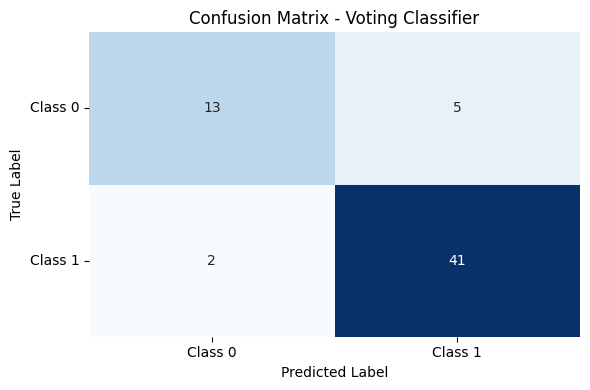

In [14]:
cm = confusion_matrix(y_test, y_pred_scaled)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Voting Classifier')
plt.xticks(ticks=[0.5, 1.5], labels=['Class 0', 'Class 1'])
plt.yticks(ticks=[0.5, 1.5], labels=['Class 0', 'Class 1'], rotation=0)
plt.tight_layout()
plt.show()

# UNSUPERVISED

In [15]:
# df1 = pd.read_csv('CAD_csv_file.csv')

Menggunakan 1 Feature

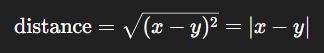

In [16]:
from matplotlib import cm

# Untuk visualisasi per iterasi
def plot_iteration(data, centroids, labels, iteration):
    plt.figure(figsize=(6, 4))
    colors = cm.tab10(labels)
    plt.scatter(data[:, 0], np.zeros_like(data[:, 0]), c=colors, s=40, label='Data')
    plt.scatter(centroids, np.zeros_like(centroids), c='red', s=100, marker='X', label='Centroids')
    plt.title(f"Iterasi {iteration}")
    plt.xlabel("Age")
    plt.yticks([])
    plt.legend()
    plt.grid(True)
    plt.show()

In [17]:
age_data = df1[['Age']].values

# Untuk awalan penempatan centroid
np.random.seed(42)
k = 2
centroids = np.random.choice(age_data.flatten(), size=k, replace=False)

converged = False
iteration = 0
previous_centroids = np.zeros_like(centroids)

SSE dan Elbow Method

In [18]:
def calculate_sse_1d(data, centroids, labels):
    sse = 0
    for i in range(len(centroids)):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i]) ** 2)
    return sse

sse_scores = {}
sse_scores_list = []

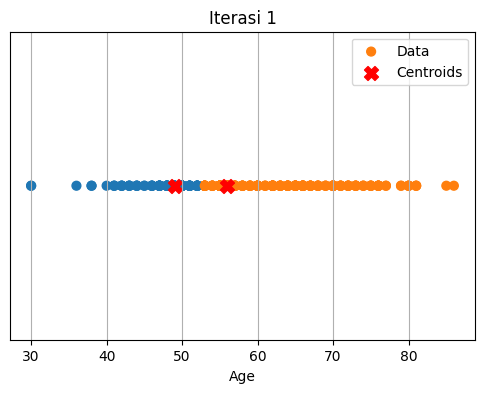

k=2 SSE: 14358.00


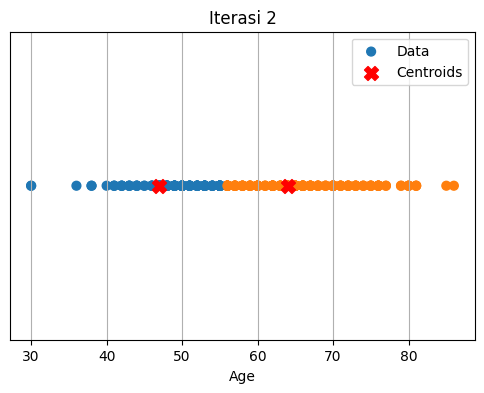

k=2 SSE: 11867.00


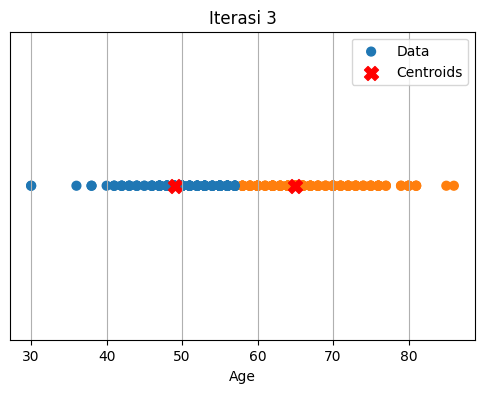

k=2 SSE: 10364.00


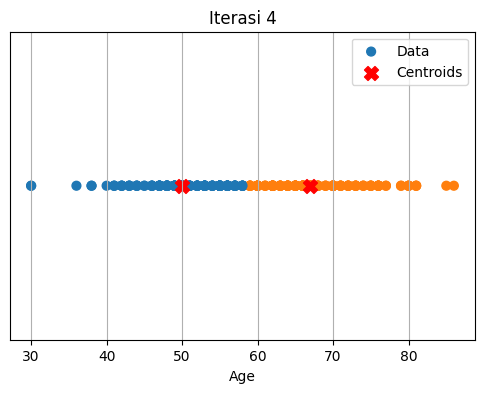

k=2 SSE: 10262.00


In [19]:
# Simpan hasil visualisasi setiap iterasi
while not np.allclose(centroids, previous_centroids):
    iteration += 1
    # Hitung jarak ke masing-masing centroid dan label klaster
    distances = np.abs(age_data - centroids.reshape(1, -1))
    labels = np.argmin(distances, axis=1)

    # Simpan visualisasi
    plot_iteration(age_data, centroids, labels, iteration)

    # Update centroid
    previous_centroids = centroids.copy()
    for i in range(k):
        centroids[i] = age_data[labels == i].mean()


    # Hitung SSE dan simpan
    sse = calculate_sse_1d(age_data, centroids, labels)
    sse_scores[k] = sse
    sse_scores_list.append(sse)
    print(f"k={k} SSE: {sse:.2f}")

In [20]:
sse_scores_list

[np.int64(14358), np.int64(11867), np.int64(10364), np.int64(10262)]

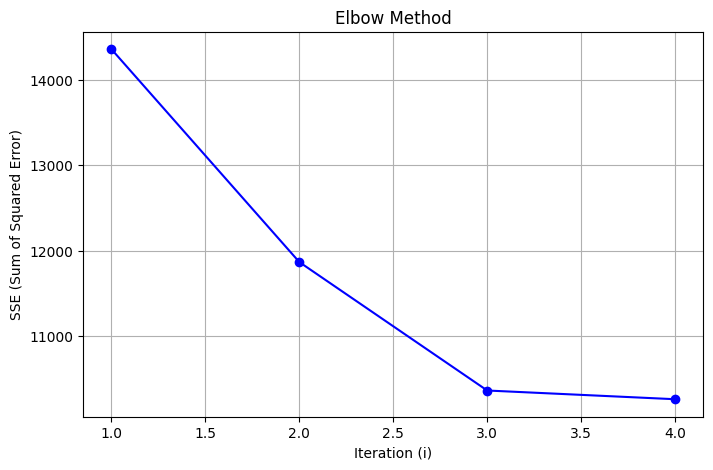

In [21]:
plt.figure(figsize=(8, 5))

# Buat list x-axis mulai dari 1
x = list(range(1, len(sse_scores_list) + 1))

plt.plot(x, sse_scores_list, marker='o', color='blue')
plt.xlabel("Iteration (i)")
plt.ylabel("SSE (Sum of Squared Error)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

Menggunakan 2 Features




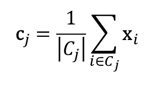

In [22]:
data = df1[['Age', 'BMI']].values

# Untuk visualisasi setiap iterasi
def plot_iteration_2d(data, centroids, labels, iteration):
    plt.figure(figsize=(6, 5))
    colors = cm.tab10(labels)
    plt.scatter(data[:, 0], data[:, 1], c=colors, s=40, label='Data')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='X', label='Centroids')
    plt.xlabel('Age')
    plt.ylabel('BMI')
    plt.title(f"Iterasi {iteration}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [23]:
# Untuk penempatan centroid awal
np.random.seed(42)
k = 2
initial_idx = np.random.choice(data.shape[0], size=k, replace=False)
centroids = data[initial_idx]

# Loop iterasi K-Means
iteration = 0
previous_centroids = np.zeros_like(centroids)

In [24]:
def calculate_sse_2d(data, centroids, labels):
    sse = 0
    for i in range(len(centroids)):
        cluster_data = data[labels == i]
        sse += np.sum((cluster_data - centroids[i]) ** 2)
    return sse
sse_scores2d = {}
sse_scores_list2 = []

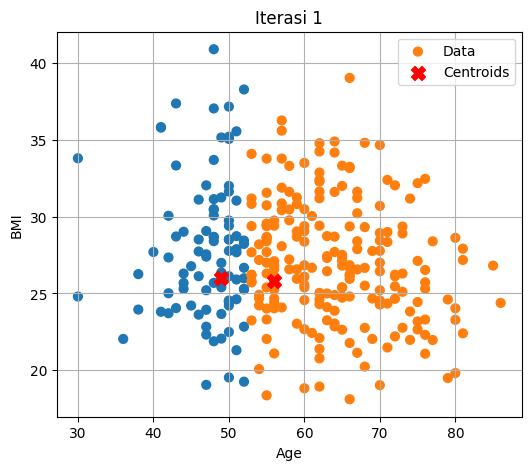

k=2 SSE: 19383.40


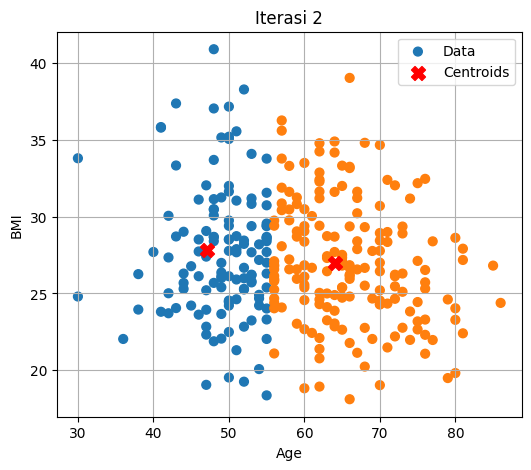

k=2 SSE: 16761.06


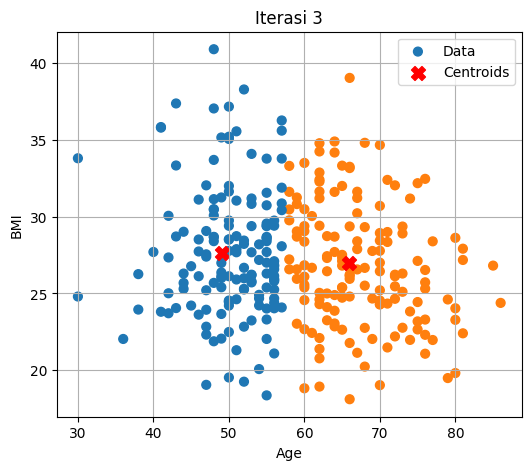

k=2 SSE: 15361.05


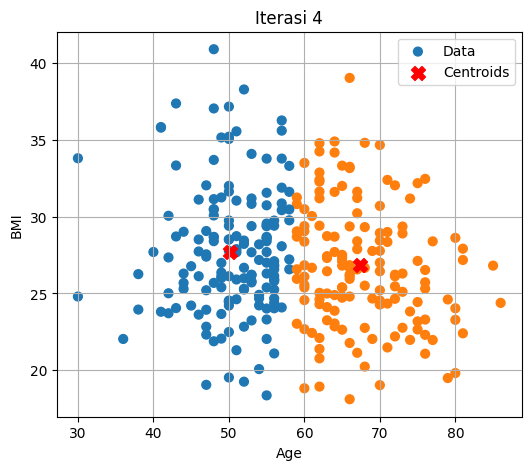

k=2 SSE: 15140.54


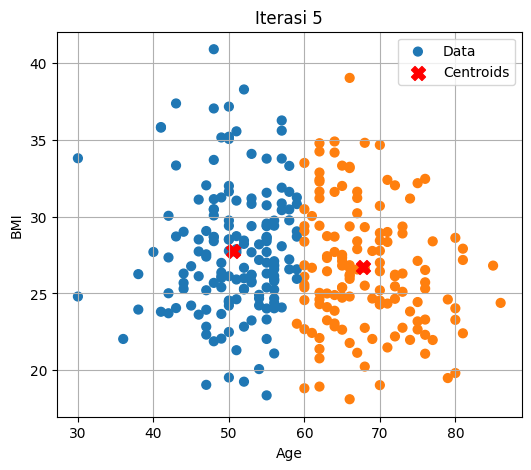

k=2 SSE: 15065.03


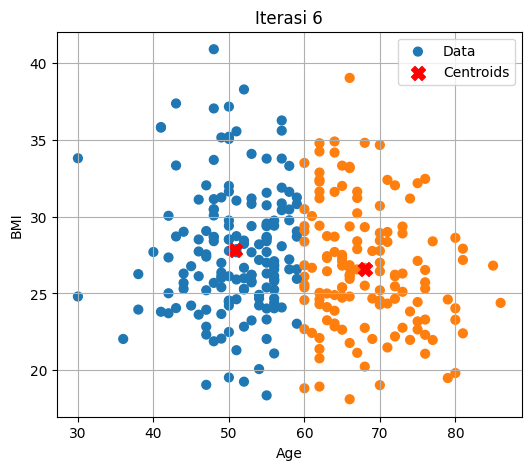

k=2 SSE: 15058.46


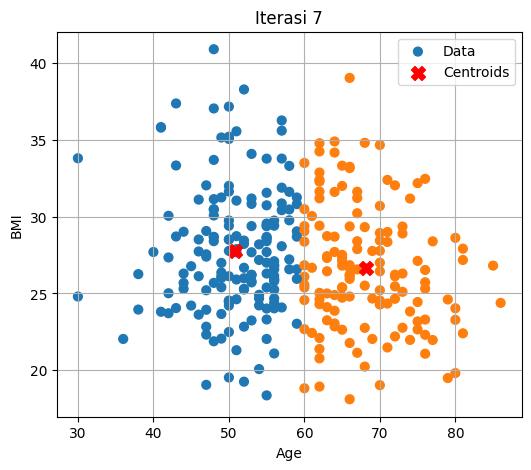

k=2 SSE: 15058.46


In [25]:
while not np.allclose(centroids, previous_centroids):
    iteration += 1

    # Hitung jarak Euclidean ke semua centroid
    distances = np.linalg.norm(data[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
    labels = np.argmin(distances, axis=1)

    # Visualisasi
    plot_iteration_2d(data, centroids, labels, iteration)

    # Update centroid
    previous_centroids = centroids.copy()
    for i in range(k):
        centroids[i] = data[labels == i].mean(axis=0)

    sse = calculate_sse_2d(data, centroids, labels)
    sse_scores2d[k] = sse
    sse_scores_list2.append(sse)
    print(f"k={k} SSE: {sse:.2f}")

In [26]:
sse_scores_list2

[np.float64(19383.39749940434),
 np.float64(16761.05835914254),
 np.float64(15361.050164427026),
 np.float64(15140.536620023744),
 np.float64(15065.032136563494),
 np.float64(15058.464896755377),
 np.float64(15058.464896755377)]

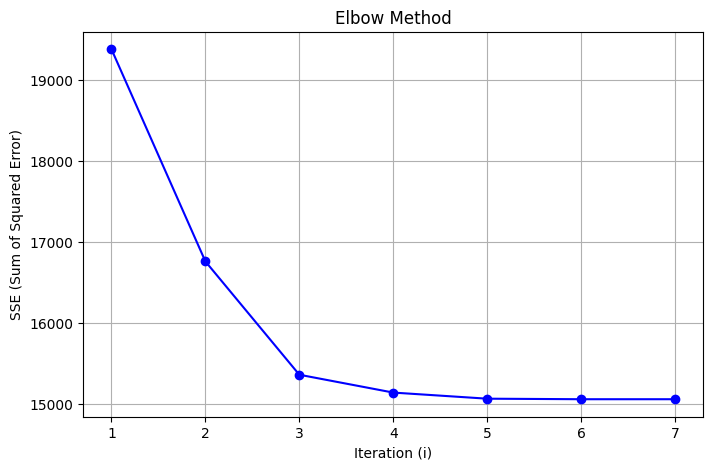

In [27]:
plt.figure(figsize=(8, 5))

# Buat list x-axis mulai dari 1
x = list(range(1, len(sse_scores_list2) + 1))

plt.plot(x, sse_scores_list2, marker='o', color='blue')
plt.xlabel("Iteration (i)")
plt.ylabel("SSE (Sum of Squared Error)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()